# Urdu Sentiment Analysis — Transfer Learning with DistilBERT Multilingual
### PyTorch + HuggingFace Transformers (MacBook Air 2025 MPS + Python 3.9)

| Property | Value |
|---|---|
| **Model** | `distilbert-base-multilingual-cased` (~134M params) |
| **Task** | Binary sentiment: Negative / Positive |
| **Datasets** | Urdu Script corpus + Roman Urdu + Daraz Reviews |
| **Strategy 1** | Full Fine-Tuning — all parameters updated |
| **Strategy 2** | LoRA PEFT — <1% parameters updated |
| **Framework** | PyTorch + HuggingFace Transformers |
| **Runtime** | macOS Apple Silicon (MPS) with CPU fallback |
| **Python** | 3.9.x compatible pinned package set |


## Section 0 — Installation

In [2]:
# Python 3.9 compatible package set for Apple Silicon (MPS)
%pip install -U pip
%pip install -U \
    torch==2.2.2 torchvision==0.17.2 torchaudio==2.2.2 \
    transformers==4.41.2 datasets==2.19.1 peft==0.11.1 accelerate==0.31.0 \
    sentencepiece==0.2.0 scikit-learn==1.4.2 matplotlib seaborn tqdm pandas numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.0
    Uninstalling pip-26.0:
      Successfully uninstalled pip-26.0
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 MB 1.3 MB/s  0:00:44m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 1.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 1.5 MB/

## Section 1 — Imports & Configuration

In [1]:
import os
import re
import gc
import sys
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    precision_recall_fscore_support, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
BASE_DIR = os.getcwd()
URDU_TSV = os.path.join(BASE_DIR, 'urdu-sentiment-corpus-v1.tsv')
ROMAN_CSV = os.path.join(BASE_DIR, 'Roman Urdu DataSet.csv')
DARAZ_CSV = os.path.join(BASE_DIR, 'darazreviews.csv')

# Force Apple Silicon GPU (MPS) only
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
if not torch.backends.mps.is_available():
    raise RuntimeError(
        'Apple GPU (MPS) is not available. This notebook is configured for GPU-only execution.'
    )
DEVICE = 'mps'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print(f'Python   : {sys.version.split()[0]}')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print('GPU      : Apple Silicon (MPS)')
print(f'BASE_DIR : {BASE_DIR}')
print('\n✅ MPS GPU-only mode enabled')


Python   : 3.9.6
PyTorch  : 2.2.2
Device   : mps
GPU      : Apple Silicon (MPS)
BASE_DIR : /Users/falakhakeem/Desktop/CSCI316_PROJECT_2

✅ MPS GPU-only mode enabled


## Section 2 — Load Datasets

In [2]:
urdu_df = pd.read_csv(URDU_TSV, sep='\t')
urdu_df = urdu_df.rename(columns={'Tweet': 'text', 'Class': 'raw_label'})

roman_df = pd.read_csv(
    ROMAN_CSV, header=None,
    names=['text', 'raw_label', 'extra'], usecols=[0, 1],
)

daraz_df = pd.read_csv(DARAZ_CSV)
daraz_df = daraz_df.rename(columns={'Reviews': 'text', 'Sentiment': 'raw_label'})
daraz_df = daraz_df[['text', 'raw_label']]

print('Urdu  :', urdu_df.shape,  '\n', urdu_df.head(2))
print('Roman :', roman_df.shape, '\n', roman_df.head(2))
print('Daraz :', daraz_df.shape, '\n', daraz_df.head(2))

Urdu  : (1000, 2) 
                                                 text raw_label
0  میں نے ایٹم بم بنایا ھے ۔۔۔۔او بھائی ایٹم بمب ...         P
1  چندے سے انقلاب اور عمران خان وزیر اعظم نہیں بن...         N
Roman : (20229, 2) 
                                                 text raw_label
0  Sai kha ya her kisi kay bus ki bat nhi hai lak...  Positive
1                                          sahi bt h  Positive
Daraz : (3923, 2) 
                                                 text raw_label
0      mil gya hai acha hai aur toota howa b nai hai  Positive
1  aram sy pocket may aa jta hai aur quality b ac...  Positive


## Section 3 — Label Standardisation

In [3]:
# Map source-specific label codes → canonical strings
urdu_label_map = {'P': 'Positive', 'N': 'Negative', 'O': 'Neutral'}
urdu_df['raw_label'] = urdu_df['raw_label'].map(urdu_label_map)

def standardize_label(lbl):
    if not isinstance(lbl, str): return None
    l = lbl.strip().lower()
    if 'pos' in l: return 'Positive'
    if 'neg' in l: return 'Negative'
    # Drop Neutral — binary setup for stronger baseline performance
    return None

for df in (urdu_df, roman_df, daraz_df):
    df['label'] = df['raw_label'].apply(standardize_label)
    df.dropna(subset=['text', 'label'], inplace=True)

urdu_df  = urdu_df[['text', 'label']]
roman_df = roman_df[['text', 'label']]
daraz_df = daraz_df[['text', 'label']]

print('Label counts per source (binary — Neutral dropped):')
print('Urdu  :', dict(urdu_df['label'].value_counts()))
print('Roman :', dict(roman_df['label'].value_counts()))
print('Daraz :', dict(daraz_df['label'].value_counts()))


Label counts per source (binary — Neutral dropped):
Urdu  : {'Negative': 499, 'Positive': 480}
Roman : {'Positive': 6013, 'Negative': 5286}
Daraz : {'Positive': 2372, 'Negative': 983}


## Section 4 — Combine, Stratified Split & Visualise

In [4]:
full_df = pd.concat([urdu_df, roman_df, daraz_df], ignore_index=True)
full_df = full_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

# Binary label space
label2id = {'Negative': 0, 'Positive': 1}
id2label  = {v: k for k, v in label2id.items()}

full_df['label_id'] = full_df['label'].map(label2id)
full_df = full_df.dropna(subset=['text', 'label_id'])
full_df['label_id'] = full_df['label_id'].astype(int)
full_df['text_len']  = full_df['text'].str.split().str.len()

# Stratified 80 / 20 split (train / test) matching PDF setup
train_df, test_df = train_test_split(
    full_df, test_size=0.2, random_state=SEED, stratify=full_df['label_id']
)
# Carve out 10% of train as validation
train_df, val_df = train_test_split(
    train_df, test_size=0.111, random_state=SEED, stratify=train_df['label_id']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Total : {len(full_df):,}')
print(f'Train : {len(train_df):,}  ({100*len(train_df)/len(full_df):.0f}%)')
print(f'Val   : {len(val_df):,}  ({100*len(val_df)/len(full_df):.0f}%)')
print(f'Test  : {len(test_df):,}  ({100*len(test_df)/len(full_df):.0f}%)')


Total : 15,633
Train : 11,117  (71%)
Val   : 1,389  (9%)
Test  : 3,127  (20%)


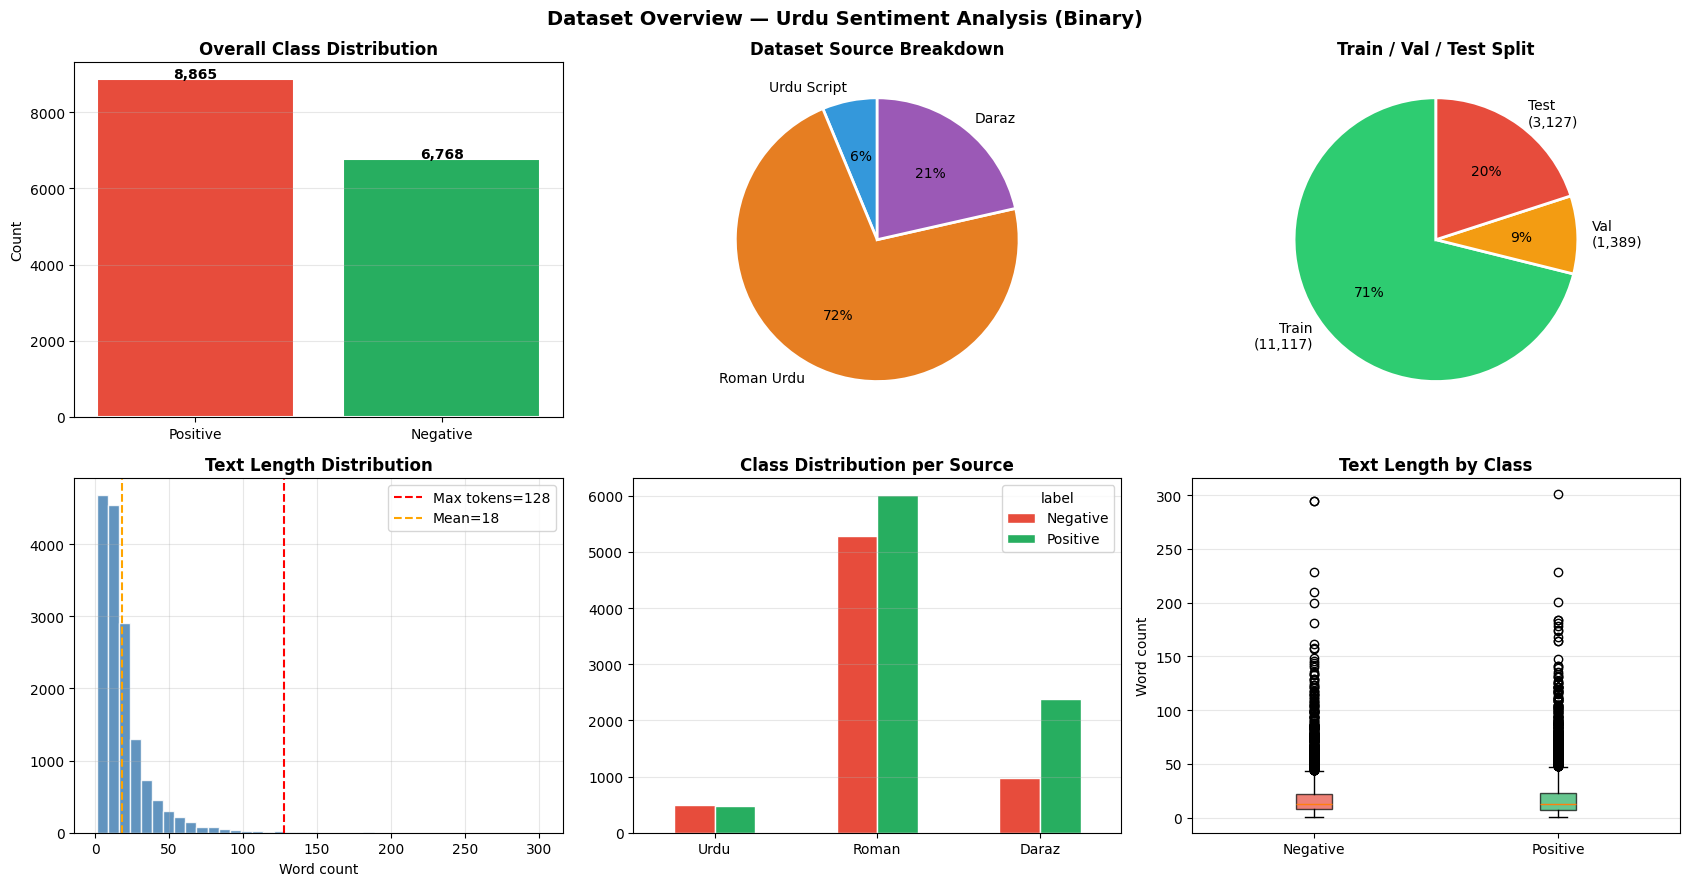

✅ dataset_overview.png saved


In [5]:
# ── Dataset Visualisations ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Dataset Overview — Urdu Sentiment Analysis (Binary)', fontsize=14, fontweight='bold')
colors_2 = ['#e74c3c', '#27ae60']

# 1. Class distribution
lc = full_df['label'].value_counts()
bars = axes[0,0].bar(lc.index, lc.values, color=colors_2, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, lc.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'{v:,}', ha='center', fontweight='bold')
axes[0,0].set_title('Overall Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count'); axes[0,0].grid(axis='y', alpha=0.3)

# 2. Source pie
sc = pd.Series({'Urdu Script': len(urdu_df), 'Roman Urdu': len(roman_df), 'Daraz': len(daraz_df)})
axes[0,1].pie(sc.values, labels=sc.index, autopct='%1.0f%%',
              colors=['#3498db','#e67e22','#9b59b6'],
              wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0,1].set_title('Dataset Source Breakdown', fontweight='bold')

# 3. Split pie
sp = [len(train_df), len(val_df), len(test_df)]
axes[0,2].pie(sp, labels=[f'Train\n({sp[0]:,})', f'Val\n({sp[1]:,})', f'Test\n({sp[2]:,})'],
              autopct='%1.0f%%', colors=['#2ecc71','#f39c12','#e74c3c'],
              wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90)
axes[0,2].set_title('Train / Val / Test Split', fontweight='bold')

# 4. Text length histogram
axes[1,0].hist(full_df['text_len'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,0].axvline(128, color='red', linestyle='--', label='Max tokens=128')
axes[1,0].axvline(full_df['text_len'].mean(), color='orange', linestyle='--',
                  label=f'Mean={full_df["text_len"].mean():.0f}')
axes[1,0].set_title('Text Length Distribution', fontweight='bold')
axes[1,0].set_xlabel('Word count'); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# 5. Per-source class breakdown
src_cls = pd.DataFrame({
    'Urdu':  urdu_df['label'].value_counts(),
    'Roman': roman_df['label'].value_counts(),
    'Daraz': daraz_df['label'].value_counts(),
}).fillna(0).T
src_cls[['Negative','Positive']].plot(
    kind='bar', ax=axes[1,1], color=colors_2, edgecolor='white'
)
axes[1,1].set_title('Class Distribution per Source', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0); axes[1,1].grid(axis='y', alpha=0.3)

# 6. Text length by class (boxplot)
data_by_class = [full_df[full_df['label']==lbl]['text_len'].values
                 for lbl in ['Negative','Positive']]
bp = axes[1,2].boxplot(data_by_class, labels=['Negative','Positive'], patch_artist=True)
for patch, c in zip(bp['boxes'], colors_2):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,2].set_title('Text Length by Class', fontweight='bold')
axes[1,2].set_ylabel('Word count'); axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ dataset_overview.png saved')


## Section 5 — Text Normalisation

In [8]:
def normalize_urdu(text: str) -> str:
    if not isinstance(text, str): return ''
    text = re.sub('[ىي]', 'ی', text)
    text = re.sub('[ۀھ]', 'ہ', text)
    text = re.sub('ـ', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_roman_urdu(text: str) -> str:
    if not isinstance(text, str): return ''
    t = text.lower()
    t = re.sub(r'\b(nai|ni)\b',       'nahi',  t)
    t = re.sub(r'\b(bohat+|boht+)\b', 'bohat', t)
    t = re.sub(r'\b(acha+|achha+)\b', 'acha',  t)
    t = re.sub(r'\b(bhut|bht)\b',     'bohat', t)
    t = re.sub(r'\b(kuch|kch)\b',     'kuch',  t)
    t = re.sub(r'\b(hain|hn)\b',      'hain',  t)
    t = re.sub(r'(lol+|haha+|hehe+)', 'haha',  t)
    t = re.sub(r'!+', '!', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def normalize_mixed(text: str) -> str:
    """Auto-detect Urdu script vs Roman Urdu and normalise accordingly."""
    if not isinstance(text, str): return ''
    if any('\u0600' <= ch <= '\u06FF' for ch in text):
        return normalize_urdu(text)
    return normalize_roman_urdu(text)

for s in ['bohat bhut acha tha!!!', 'بیکار هے یه', 'nai mujhe pasand nai aya']:
    print(f'  RAW  : {s}')
    print(f'  NORM : {normalize_mixed(s)}\n')

  RAW  : bohat bhut acha tha!!!
  NORM : bohat bohat acha tha!

  RAW  : بیکار هے یه
  NORM : بیکار هے یه

  RAW  : nai mujhe pasand nai aya
  NORM : nahi mujhe pasand nahi aya



## Section 6 — Tokenisation

In [9]:
model_name = 'distilbert-base-multilingual-cased'
tokenizer  = AutoTokenizer.from_pretrained(model_name)
MAX_LEN    = 128
BATCH_SIZE = 16

print(f'Model           : {model_name}')
print(f'Vocabulary size : {tokenizer.vocab_size:,}')

# ── PyTorch Dataset (manual loop approach) ────────────────────────────────────
class SentimentDataset(TorchDataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts  = df['text'].tolist()
        self.labels = df['label_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            normalize_mixed(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = SentimentDataset(train_df, tokenizer, MAX_LEN)
val_ds   = SentimentDataset(val_df,   tokenizer, MAX_LEN)
test_ds  = SentimentDataset(test_df,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'\n✅ Tokenisation complete')
print(f'   Train : {len(train_ds):,}')
print(f'   Val   : {len(val_ds):,}')
print(f'   Test  : {len(test_ds):,}')


Model           : distilbert-base-multilingual-cased
Vocabulary size : 119,547

✅ Tokenisation complete
   Train : 11,117
   Val   : 1,389
   Test  : 3,127


## Section 7 — Custom Training Loop, Class Weights & Metrics


In [10]:
# ── Class weights ────────────────────────────────────────────────────────────
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label_id'].values,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print('Class weights:')
for i, (lbl, w) in enumerate(zip(['Negative','Positive'], class_weights)):
    count = (train_df['label_id'] == i).sum()
    print(f'  {lbl:10s} : {w:.4f}  (train count={count:,})')

# ── Custom PyTorch training loop ──────────────────────────────────────────────
def train_model(model, train_loader, val_loader, epochs=2, lr=2e-5):
    model.to(DEVICE)
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_loader) * epochs
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.1 * total_steps)),
        num_training_steps=total_steps
    )
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
    history = []

    for epoch in range(epochs):
        # ── Train ──
        model.train()
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [train]', leave=False):
            batch     = {k: v.to(DEVICE) for k, v in batch.items()}
            labels    = batch.pop('labels')
            outputs   = model(**batch)
            loss      = loss_fn(outputs.logits, labels)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # ── Validate ──
        val_metrics, _ = evaluate_model(model, val_loader)
        history.append({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            **{f'val_{k}': v for k, v in val_metrics.items()}
        })
        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Val Acc: {val_metrics["accuracy"]:.4f} | '
              f'Val F1: {val_metrics["f1"]:.4f}')
    return history

# ── Evaluation function ───────────────────────────────────────────────────────
def evaluate_model(model, data_loader):
    model.eval()
    preds, labels_list = [], []
    with torch.no_grad():
        for batch in data_loader:
            y_true = batch['labels'].numpy()
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask']
            ).logits
            y_pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(y_pred.tolist())
            labels_list.extend(y_true.tolist())
    acc = accuracy_score(labels_list, preds)
    p, r, f1, _ = precision_recall_fscore_support(
        labels_list, preds, average='binary', zero_division=0
    )
    f1_per_class = f1_score(labels_list, preds, average=None, labels=[0,1], zero_division=0)
    metrics = {
        'accuracy':    round(acc, 4),
        'precision':   round(p,   4),
        'recall':      round(r,   4),
        'f1':          round(f1,  4),
        'f1_macro':    round(f1_score(labels_list, preds, average='macro',    zero_division=0), 4),
        'f1_weighted': round(f1_score(labels_list, preds, average='weighted', zero_division=0), 4),
        'f1_negative': round(f1_per_class[0], 4),
        'f1_positive': round(f1_per_class[1], 4),
    }
    return metrics, (labels_list, preds)

print('\n✅ Custom train_model, evaluate_model ready')


Class weights:
  Negative   : 1.1549  (train count=4,813)
  Positive   : 0.8817  (train count=6,304)

✅ Custom train_model, evaluate_model ready


## Section 8A — Transfer Strategy 1: Full Fine-Tuning

All ~134M DistilBERT-multilingual parameters updated. AdamW + linear warmup scheduler.


In [11]:
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
elif DEVICE == 'mps' and hasattr(torch.mps, 'empty_cache'):
    torch.mps.empty_cache()
gc.collect()

model_full = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id,
).to(DEVICE)

total_params = sum(p.numel() for p in model_full.parameters())
print(f'Model           : {model_name}')
print(f'Total params    : {total_params:,} ({total_params/1e6:.0f}M)')
if DEVICE == 'cuda':
    print(f'GPU memory      : {torch.cuda.memory_allocated()/1e9:.2f} GB')
elif DEVICE == 'mps':
    print('Backend         : Apple Silicon MPS')


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model           : distilbert-base-multilingual-cased
Total params    : 135,326,210 (135M)
Backend         : Apple Silicon MPS


In [12]:
EPOCHS = 4   # Increase to 3-4 if accuracy below 70%
LR     = 2e-5

print('=' * 55)
print('FULL FINE-TUNING — START')
print('=' * 55)
t0 = time.time()
full_history = train_model(model_full, train_loader, val_loader, epochs=EPOCHS, lr=LR)
full_train_time = time.time() - t0
print(f'\n✅ Complete! Time: {full_train_time/60:.1f} min')

full_metrics, (full_labels, full_preds) = evaluate_model(model_full, test_loader)
print('\nFull Fine-Tuning — Test Set Metrics:')
for k, v in full_metrics.items():
    print(f'  {k:20s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(full_labels, full_preds, target_names=['negative', 'positive']))


FULL FINE-TUNING — START


Epoch 1/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 1/4 | Train Loss: 0.5938 | Val Acc: 0.7509 | Val F1: 0.7543


Epoch 2/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 2/4 | Train Loss: 0.4347 | Val Acc: 0.7545 | Val F1: 0.7407


Epoch 3/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 3/4 | Train Loss: 0.3122 | Val Acc: 0.7963 | Val F1: 0.8112


Epoch 4/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 4/4 | Train Loss: 0.2228 | Val Acc: 0.7963 | Val F1: 0.8194

✅ Complete! Time: 46.9 min

Full Fine-Tuning — Test Set Metrics:
  accuracy            : 0.7787
  precision           : 0.8080
  recall              : 0.7998
  f1                  : 0.8039
  f1_macro            : 0.7750
  f1_weighted         : 0.7789
  f1_negative         : 0.7461
  f1_positive         : 0.8039

Classification Report:
              precision    recall  f1-score   support

    negative       0.74      0.75      0.75      1354
    positive       0.81      0.80      0.80      1773

    accuracy                           0.78      3127
   macro avg       0.77      0.78      0.78      3127
weighted avg       0.78      0.78      0.78      3127



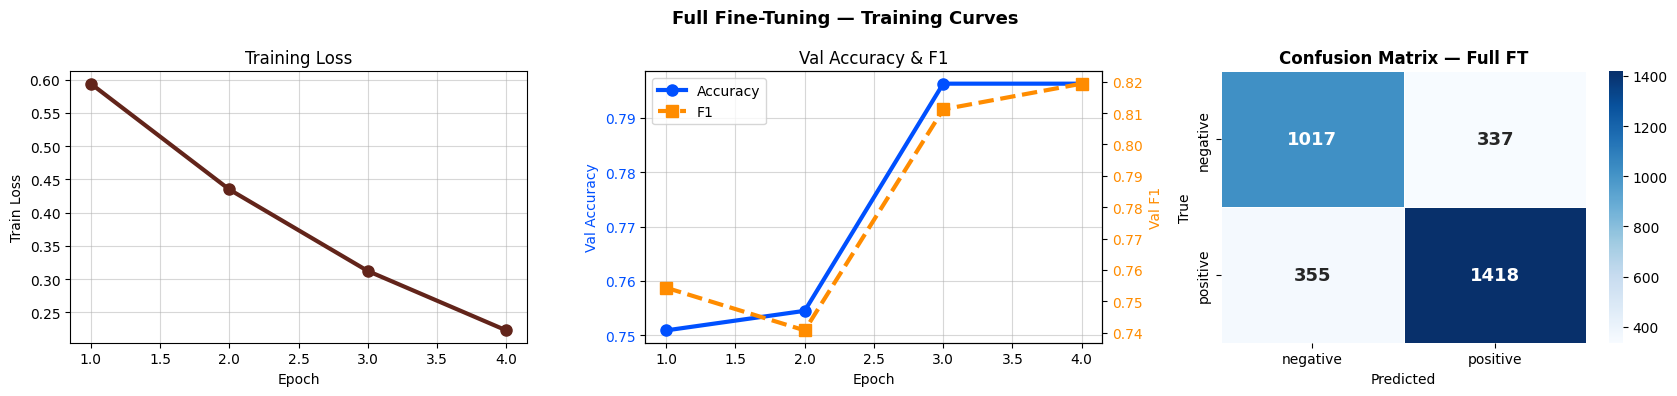

In [13]:
# ── Full FT Training Curves ───────────────────────────────────────────────────
epochs_range = [h['epoch'] for h in full_history]
train_losses = [h['train_loss'] for h in full_history]
val_losses   = [h.get('val_loss', 0) for h in full_history]
val_accs     = [h['val_accuracy'] for h in full_history]
val_f1s      = [h['val_f1'] for h in full_history]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Full Fine-Tuning — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, train_losses, 'o-', color="#62241A", linewidth=3, markersize=8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.5)

axes[1].plot(epochs_range, val_accs, 'o-', color='#0050FF', linewidth=3, markersize=8, label='Accuracy')
ax2 = axes[1].twinx()
ax2.plot(epochs_range, val_f1s, 's--', color='#FF8C00', linewidth=3, markersize=8, label='F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy', color='#0050FF')
ax2.set_ylabel('Val F1', color='#FF8C00')
axes[1].tick_params(axis='y', labelcolor='#0050FF')
ax2.tick_params(axis='y', labelcolor='#FF8C00')
axes[1].set_title('Val Accuracy & F1')
l1, lb1 = axes[1].get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
axes[1].legend(l1+l2, lb1+lb2); axes[1].grid(alpha=0.5)

# Confusion matrix
cm = confusion_matrix(full_labels, full_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Blues',
            xticklabels=['negative','positive'], yticklabels=['negative','positive'],
            linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
axes[2].set_title('Confusion Matrix — Full FT', fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('full_ft_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8B — Transfer Strategy 2: LoRA PEFT

Only low-rank adapter matrices A and B are trained. For weight $W \in \mathbb{R}^{d \times k}$:
$$\Delta W = BA, \quad B \in \mathbb{R}^{d \times r},\ A \in \mathbb{R}^{r \times k},\ r \ll \min(d,k)$$

DistilBERT attention modules: `q_lin`, `k_lin`, `v_lin` (DistilBERT-specific names)


In [14]:
if DEVICE == 'cuda':
    torch.cuda.empty_cache()
elif DEVICE == 'mps' and hasattr(torch.mps, 'empty_cache'):
    torch.mps.empty_cache()
gc.collect()

base_lora = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id,
)

# DistilBERT uses q_lin / k_lin / v_lin for attention projections
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin'],
    bias='none',
)
model_lora = get_peft_model(base_lora, lora_config).to(DEVICE)

lora_trainable = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
lora_total     = sum(p.numel() for p in model_lora.parameters())
lora_pct       = 100 * lora_trainable / lora_total

print(f'\nLoRA PEFT — DistilBERT-multilingual')
print(f'   Total params     : {lora_total:,} ({lora_total/1e6:.0f}M)')
print(f'   Trainable params : {lora_trainable:,} ({lora_trainable/1e6:.2f}M)')
print(f'   Trainable %      : {lora_pct:.4f}%')
model_lora.print_trainable_parameters()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



LoRA PEFT — DistilBERT-multilingual
   Total params     : 136,139,524 (136M)
   Trainable params : 813,314 (0.81M)
   Trainable %      : 0.5974%
trainable params: 813,314 || all params: 136,139,524 || trainable%: 0.5974


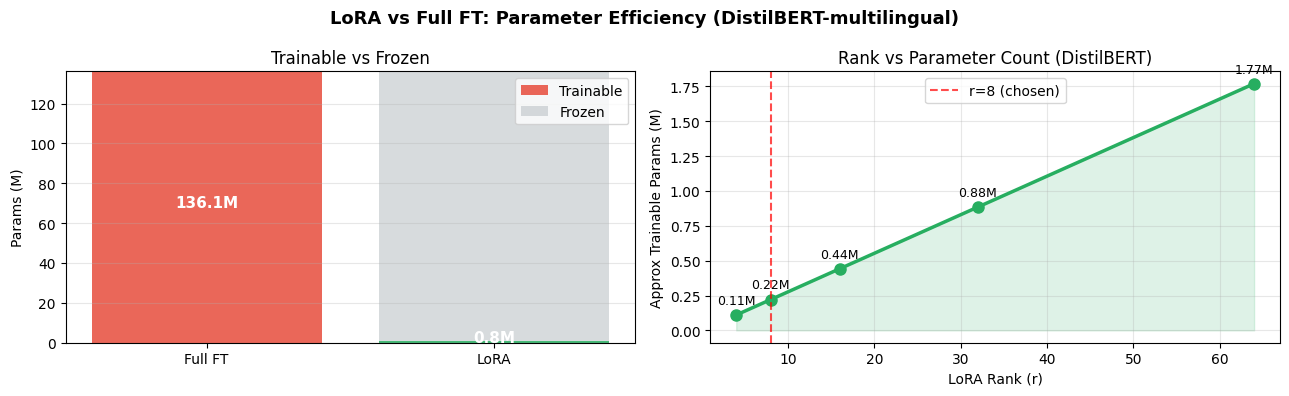

Reduction: 99.4% fewer trainable params with LoRA


In [15]:
# ── LoRA Param Efficiency Visualisation ──────────────────────────────────────
# DistilBERT: 6 layers, 768 hidden dim, 3 target modules (q/k/v)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('LoRA vs Full FT: Parameter Efficiency (DistilBERT-multilingual)', fontsize=13, fontweight='bold')

# total_params was set from model_full before deletion; re-derive if needed
_total = lora_total  # approx same as full model (LoRA only adds tiny adapters)
x = np.arange(2)
t_m = [_total/1e6, lora_trainable/1e6]
f_m = [0, (lora_total - lora_trainable)/1e6]
b1 = axes[0].bar(x, t_m, color=['#e74c3c','#27ae60'], alpha=0.85, label='Trainable')
axes[0].bar(x, f_m, bottom=t_m, color='#bdc3c7', alpha=0.6, label='Frozen')
axes[0].set_xticks(x); axes[0].set_xticklabels(['Full FT', 'LoRA'])
axes[0].set_ylabel('Params (M)'); axes[0].set_title('Trainable vs Frozen')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(b1, t_m):
    axes[0].text(bar.get_x()+bar.get_width()/2, max(v/2, 0.5),
                f'{v:.1f}M', ha='center', fontweight='bold', color='white', fontsize=11)

# Rank sensitivity — DistilBERT: 6 layers, 3 modules (q/k/v), hidden=768
ranks = [4, 8, 16, 32, 64]
approx = [6 * 3 * 2 * r * 768 / 1e6 for r in ranks]
axes[1].plot(ranks, approx, 'o-', color='#27ae60', linewidth=2.5, markersize=8)
axes[1].axvline(8, color='red', linestyle='--', alpha=0.7, label='r=8 (chosen)')
axes[1].fill_between(ranks, approx, alpha=0.15, color='#27ae60')
for r, t in zip(ranks, approx):
    axes[1].annotate(f'{t:.2f}M', (r, t), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
axes[1].set_xlabel('LoRA Rank (r)'); axes[1].set_ylabel('Approx Trainable Params (M)')
axes[1].set_title('Rank vs Parameter Count (DistilBERT)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lora_params.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Reduction: {100*(1-lora_trainable/lora_total):.1f}% fewer trainable params with LoRA')


In [16]:
LORA_EPOCHS = 4   # LoRA converges fast; bump to 3 if needed
LORA_LR     = 2e-5  # Higher LR for adapter-only updates

print('=' * 55)
print('LoRA PEFT FINE-TUNING — START')
print('=' * 55)
t0 = time.time()
lora_history = train_model(model_lora, train_loader, val_loader, epochs=LORA_EPOCHS, lr=LORA_LR)
lora_train_time = time.time() - t0
print(f'\n✅ Complete! Time: {lora_train_time/60:.1f} min')

lora_metrics, (lora_labels, lora_preds) = evaluate_model(model_lora, test_loader)
print('\nLoRA PEFT — Test Set Metrics:')
for k, v in lora_metrics.items():
    print(f'  {k:20s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(lora_labels, lora_preds, target_names=['negative', 'positive']))


LoRA PEFT FINE-TUNING — START


Epoch 1/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 1/4 | Train Loss: 0.6810 | Val Acc: 0.6544 | Val F1: 0.6985


Epoch 2/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 2/4 | Train Loss: 0.6263 | Val Acc: 0.6739 | Val F1: 0.7045


Epoch 3/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 3/4 | Train Loss: 0.5914 | Val Acc: 0.6875 | Val F1: 0.7003


Epoch 4/4 [train]:   0%|          | 0/695 [00:00<?, ?it/s]

Epoch 4/4 | Train Loss: 0.5776 | Val Acc: 0.6933 | Val F1: 0.7094

✅ Complete! Time: 27.3 min

LoRA PEFT — Test Set Metrics:
  accuracy            : 0.6687
  precision           : 0.7439
  recall              : 0.6340
  f1                  : 0.6845
  f1_macro            : 0.6679
  f1_weighted         : 0.6701
  f1_negative         : 0.6512
  f1_positive         : 0.6845

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.71      0.65      1354
    positive       0.74      0.63      0.68      1773

    accuracy                           0.67      3127
   macro avg       0.67      0.67      0.67      3127
weighted avg       0.68      0.67      0.67      3127



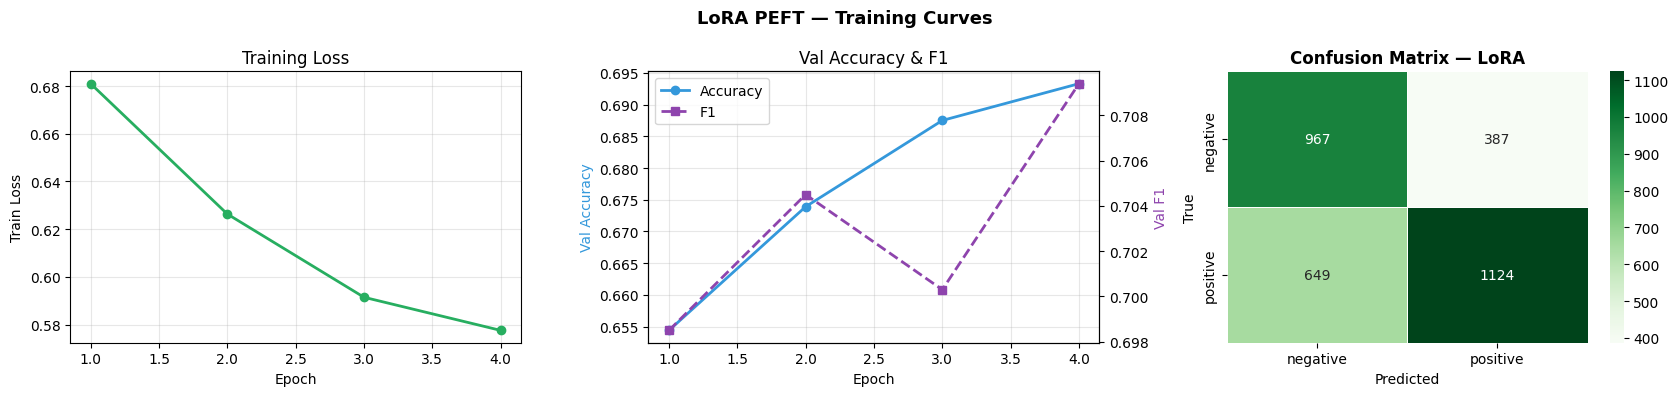

In [17]:
# ── LoRA Training Curves ──────────────────────────────────────────────────────
l_epochs = [h['epoch']      for h in lora_history]
l_losses = [h['train_loss'] for h in lora_history]
l_accs   = [h['val_accuracy'] for h in lora_history]
l_f1s    = [h['val_f1']      for h in lora_history]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('LoRA PEFT — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(l_epochs, l_losses, 'o-', color='#27ae60', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3)

axes[1].plot(l_epochs, l_accs, 'o-', color='#3498db', linewidth=2, label='Accuracy')
ax2 = axes[1].twinx()
ax2.plot(l_epochs, l_f1s, 's--', color='#8e44ad', linewidth=2, label='F1')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy', color='#3498db')
ax2.set_ylabel('Val F1', color='#8e44ad')
axes[1].set_title('Val Accuracy & F1')
l1, lb1 = axes[1].get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
axes[1].legend(l1+l2, lb1+lb2); axes[1].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(lora_labels, lora_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[2], cmap='Greens',
            xticklabels=['negative','positive'], yticklabels=['negative','positive'],
            linewidths=0.5)
axes[2].set_title('Confusion Matrix — LoRA', fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('lora_curves.png', dpi=150, bbox_inches='tight')
plt.show()


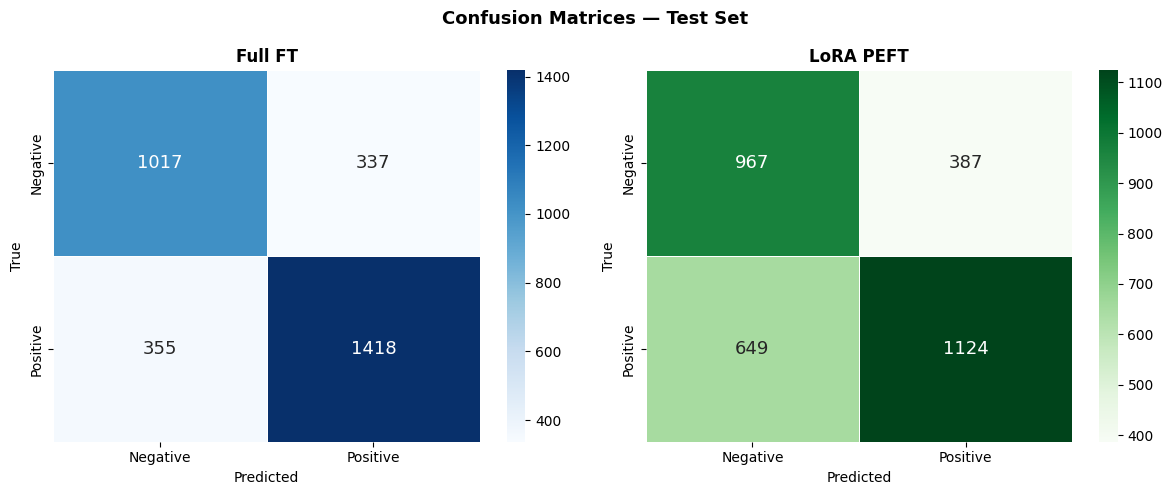

In [18]:
# ── Side-by-side confusion matrices ─────────────────────────────────────────
class_names = ['Negative', 'Positive']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')

for ax, preds, lbls, title, cmap in zip(
    axes,
    [full_preds, lora_preds],
    [full_labels, lora_labels],
    ['Full FT', 'LoRA PEFT'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(lbls, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cmap=cmap, linewidths=0.5, annot_kws={'size': 13})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 9 — Final Evaluation on Test Set

In [19]:
# ── Final Test Evaluation ────────────────────────────────────────────────────
# Both models already evaluated at end of training cells.
# This cell re-confirms and prints a clean comparison.

model_full.eval()
model_lora.eval()

results_full = {f'test_{k}': v for k, v in full_metrics.items()}
results_lora = {f'test_{k}': v for k, v in lora_metrics.items()}

print('Full Fine-Tuning — Test Set')
for k in ['test_accuracy','test_f1_macro','test_f1_weighted','test_f1_negative','test_f1_positive']:
    print(f'  {k.replace("test_",""):20s}: {results_full[k]:.4f}')

print('\nLoRA PEFT — Test Set')
for k in ['test_accuracy','test_f1_macro','test_f1_weighted','test_f1_negative','test_f1_positive']:
    print(f'  {k.replace("test_",""):20s}: {results_lora[k]:.4f}')


Full Fine-Tuning — Test Set
  accuracy            : 0.7787
  f1_macro            : 0.7750
  f1_weighted         : 0.7789
  f1_negative         : 0.7461
  f1_positive         : 0.8039

LoRA PEFT — Test Set
  accuracy            : 0.6687
  f1_macro            : 0.6679
  f1_weighted         : 0.6701
  f1_negative         : 0.6512
  f1_positive         : 0.6845


In [20]:
# ── Get predictions for evaluation dashboard ─────────────────────────────────
# Already computed during training; aliased here for downstream cells
preds_full   = np.array(full_preds)
preds_lora   = np.array(lora_preds)
labels_test  = np.array(full_labels)   # same test set for both
print('✅ Predictions ready')
print(f'   Full FT accuracy : {accuracy_score(labels_test, preds_full):.4f}')
print(f'   LoRA    accuracy : {accuracy_score(labels_test, preds_lora):.4f}')


✅ Predictions ready
   Full FT accuracy : 0.7787
   LoRA    accuracy : 0.6687


In [21]:
# ── Confusion matrices already plotted above in cell 28 ─────────────────────
# Reprinting text-only summary here for completeness
print('Confusion Matrix — Full FT:')
print(confusion_matrix(labels_test, preds_full))
print('\nConfusion Matrix — LoRA:')
print(confusion_matrix(labels_test, preds_lora))


Confusion Matrix — Full FT:
[[1017  337]
 [ 355 1418]]

Confusion Matrix — LoRA:
[[ 967  387]
 [ 649 1124]]


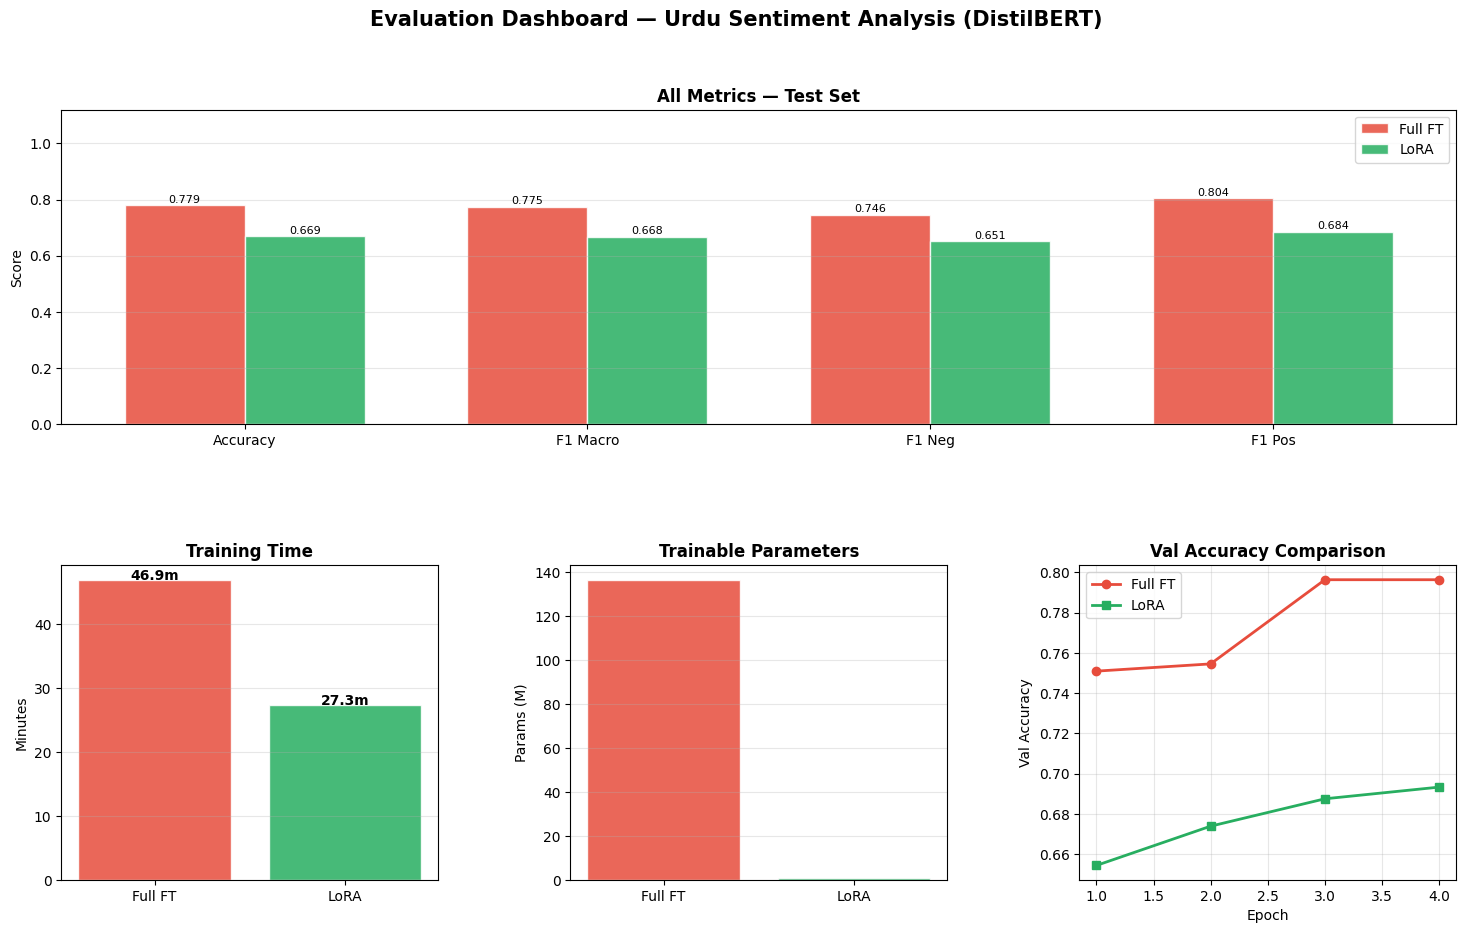

In [22]:
# ── Comprehensive Evaluation Dashboard ───────────────────────────────────────
m_full  = [results_full['test_accuracy'], results_full['test_f1_macro'],
           results_full['test_f1_negative'], results_full['test_f1_positive']]
m_lora  = [results_lora['test_accuracy'], results_lora['test_f1_macro'],
           results_lora['test_f1_negative'], results_lora['test_f1_positive']]
mnames  = ['Accuracy','F1 Macro','F1 Neg','F1 Pos']

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Evaluation Dashboard — Urdu Sentiment Analysis (DistilBERT)',
             fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# All metrics grouped bar
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(mnames)); w = 0.35
b1 = ax1.bar(x-w/2, m_full, w, label='Full FT', color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax1.bar(x+w/2, m_lora, w, label='LoRA',    color='#27ae60', alpha=0.85, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(mnames)
ax1.set_ylabel('Score'); ax1.set_title('All Metrics — Test Set', fontweight='bold')
ax1.set_ylim(0, 1.12); ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in list(b1)+list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Training time
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(['Full FT','LoRA'], [full_train_time/60, lora_train_time/60],
               color=['#e74c3c','#27ae60'], edgecolor='white', alpha=0.85)
for bar, v in zip(bars, [full_train_time/60, lora_train_time/60]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{v:.1f}m', ha='center', fontweight='bold')
ax2.set_title('Training Time', fontweight='bold'); ax2.set_ylabel('Minutes'); ax2.grid(axis='y', alpha=0.3)

# Trainable params
ax3 = fig.add_subplot(gs[1, 1])
_full_total = lora_total  # same base model
ax3.bar(['Full FT','LoRA'], [_full_total/1e6, lora_trainable/1e6],
        color=['#e74c3c','#27ae60'], edgecolor='white', alpha=0.85)
ax3.set_title('Trainable Parameters', fontweight='bold')
ax3.set_ylabel('Params (M)'); ax3.grid(axis='y', alpha=0.3)

# Val accuracy over epochs
ax4 = fig.add_subplot(gs[1, 2])
full_ep = [h['epoch'] for h in full_history]
full_va = [h['val_accuracy'] for h in full_history]
lora_ep = [h['epoch'] for h in lora_history]
lora_va = [h['val_accuracy'] for h in lora_history]
ax4.plot(full_ep, full_va, 'o-', color='#e74c3c', linewidth=2, label='Full FT')
ax4.plot(lora_ep, lora_va, 's-', color='#27ae60', linewidth=2, label='LoRA')
ax4.set_title('Val Accuracy Comparison', fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Val Accuracy')
ax4.legend(); ax4.grid(alpha=0.3)

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 10 — Cultural Polarity Consistency Metric

In [23]:
cultural_lexicon = {
    # Negative — Roman Urdu
    'bohat bura':'Negative','bekar':'Negative','badter':'Negative',
    'buri':'Negative','zalim':'Negative','bakwas':'Negative',
    'ganda':'Negative','faltu':'Negative','naqis':'Negative',
    'bara ghatiya':'Negative','jhoot':'Negative','dhoka':'Negative',
    'waste':'Negative','kharab':'Negative','nikamma':'Negative',
    # Negative — Urdu script
    '\u0628\u06c1\u062a \u0628\u0631\u0627':'Negative','\u0628\u06cc\u06a9\u0627\u0631':'Negative',
    '\u062e\u0631\u0627\u0628':'Negative','\u0646\u0627\u0642\u0635':'Negative',
    '\u06af\u06be\u0679\u06cc\u0627':'Negative','\u062c\u06be\u0648\u0679':'Negative',
    # Positive — Roman Urdu
    'bohat acha':'Positive','bhot acha':'Positive','umdah':'Positive',
    'lajawaab':'Positive','kamaal':'Positive','zabardast':'Positive',
    'mast':'Positive','shandaar':'Positive','behtareen':'Positive',
    'khush':'Positive','pasand':'Positive','wah wah':'Positive',
    'achi service':'Positive','bohot achi':'Positive',
    # Positive — Urdu script
    '\u0628\u06c1\u062a\u0631\u06cc\u0646':'Positive','\u0644\u0627\u062c\u0648\u0627\u0628':'Positive',
    '\u06a9\u0645\u0627\u0644':'Positive','\u0634\u0627\u0646\u062f\u0627\u0631':'Positive',
    '\u0632\u0628\u0631\u062f\u0633\u062a':'Positive','\u062e\u0648\u0634':'Positive',
    '\u0628\u06c1\u062a \u0627\u0686\u06be\u0627':'Positive','\u0628\u06c1\u062a \u062e\u0648\u0628':'Positive',
}

def detect_cultural_phrase(text):
    if not isinstance(text, str): return None
    t = normalize_mixed(text)
    for phrase, lbl in cultural_lexicon.items():
        if phrase in t: return lbl
    return None

def cultural_polarity_consistency(model, texts, max_samples=500):
    model.eval()
    correct, total = 0, 0
    for txt in texts[:max_samples]:
        gold = detect_cultural_phrase(txt)
        if gold is None: continue
        enc = tokenizer(
            normalize_mixed(txt), return_tensors='pt',
            truncation=True, padding='max_length', max_length=128,
        ).to(DEVICE)
        with torch.no_grad():
            pred_id = model(**enc).logits.argmax(dim=-1).item()
        if id2label[pred_id] == gold: correct += 1
        total += 1
    return round(correct/total, 4) if total > 0 else 0.0, total

test_texts = test_df['text'].tolist()
cpc_full, n = cultural_polarity_consistency(model_full, test_texts)
cpc_lora, _ = cultural_polarity_consistency(model_lora,  test_texts)

print('Cultural Polarity Consistency Score')
print(f'  Full FT : {cpc_full:.4f}  ({int(cpc_full*n)}/{n} phrases correct)')
print(f'  LoRA    : {cpc_lora:.4f}  ({int(cpc_lora*n)}/{n} phrases correct)')


Cultural Polarity Consistency Score
  Full FT : 0.8182  (45/55 phrases correct)
  LoRA    : 0.7455  (41/55 phrases correct)


## Section 11 — Qualitative Inference

In [24]:
def classify_sentence(model, sentence: str) -> dict:
    model.eval()
    enc = tokenizer(
        normalize_mixed(sentence), return_tensors='pt',
        truncation=True, padding='max_length', max_length=128,
    ).to(DEVICE)
    with torch.no_grad():
        logits = model(**enc).logits
    probs   = torch.softmax(logits, dim=-1)[0].cpu().tolist()
    pred_id = int(torch.argmax(logits, dim=-1).item())
    return {
        'label':    id2label[pred_id],
        'negative': round(probs[0], 3),
        'positive': round(probs[1], 3),
    }

examples = [
    'Dil khush hogya',
    '\u06cc\u06c1 \u0628\u06cc\u06a9\u0627\u0631 \u06c1\u06d2',
    'bohat achi service thi',
    'Theek hai, kuch khaas nahi',
    '\u0628\u06c1\u062a \u0628\u0631\u0627 \u062a\u062c\u0631\u0628\u06c1 \u062a\u06be\u0627',
    'zabardast product hai yaar',
    'waste of money bilkul',
    'mil gya hai acha hai aur toota howa b nai hai',
]

print(f'{"Sentence":<40} {"Full FT":<12} {"LoRA":<12} Confidence (Full FT)')
print('-' * 86)
for sent in examples:
    rf = classify_sentence(model_full, sent)
    rl = classify_sentence(model_lora,  sent)
    conf = f"Neg={rf['negative']} Pos={rf['positive']}"
    print(f"{sent:<40} {rf['label']:<12} {rl['label']:<12} {conf}")


Sentence                                 Full FT      LoRA         Confidence (Full FT)
--------------------------------------------------------------------------------------
Dil khush hogya                          Positive     Negative     Neg=0.051 Pos=0.949
یہ بیکار ہے                              Negative     Positive     Neg=0.609 Pos=0.391
bohat achi service thi                   Positive     Positive     Neg=0.003 Pos=0.997
Theek hai, kuch khaas nahi               Positive     Negative     Neg=0.038 Pos=0.962
بہت برا تجربہ تھا                        Positive     Negative     Neg=0.005 Pos=0.995
zabardast product hai yaar               Positive     Positive     Neg=0.003 Pos=0.997
waste of money bilkul                    Negative     Negative     Neg=0.99 Pos=0.01
mil gya hai acha hai aur toota howa b nai hai Positive     Positive     Neg=0.043 Pos=0.957


## Section 12 — LoRA From Scratch (NumPy Mathematical Demo)

In [25]:
class LoRALayerNumPy:
    """
    LoRA from scratch — pure NumPy, no external libraries.

    Forward pass:
        h = x W^T  +  (alpha/r) * x A^T B^T

    Initialisation:
        A ~ N(0, 0.01)   introduces random exploration
        B = 0            ensures delta_W = 0 at start (preserves pretrained behaviour)
    """
    def __init__(self, d: int, k: int, r: int = 8, alpha: int = 16, seed: int = 42):
        rng = np.random.RandomState(seed)
        self.d, self.k, self.r = d, k, r
        self.scaling = alpha / r
        self.W = rng.randn(d, k) * 0.02   # frozen
        self.A = rng.randn(r, k) * 0.01   # trainable
        self.B = np.zeros((d, r))          # trainable, zero-init

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x @ self.W.T + (x @ self.A.T) @ self.B.T * self.scaling

    def delta_W(self) -> np.ndarray:
        return self.scaling * (self.B @ self.A)

    def stats(self) -> dict:
        frozen = self.d * self.k
        train  = self.r * self.k + self.d * self.r
        return {'frozen': frozen, 'trainable': train,
                'savings_%': round(100 * (1 - train/frozen), 2)}

# Demo on DistilBERT dims (hidden=768, r=8, alpha=16 matching our config)
layer = LoRALayerNumPy(d=768, k=768, r=8, alpha=16)
x_in  = np.random.randn(4, 768)
out   = layer.forward(x_in)
s     = layer.stats()

print('LoRA From Scratch — DistilBERT-multilingual Attention Projection')
print('=' * 60)
print(f'Layer shape        : {layer.d} × {layer.k}')
print(f'Rank r             : {layer.r}')
print(f'Scaling (alpha/r)  : {layer.scaling}')
print(f'Frozen W params    : {s["frozen"]:,}')
print(f'Trainable params   : {s["trainable"]:,}')
print(f'Parameter savings  : {s["savings_%"]}%')
print(f'ΔW initial norm    : {np.linalg.norm(layer.delta_W()):.6f}  (≈0, B=0 init)')
print(f'Forward output     : shape={out.shape}, mean={out.mean():.4f}')

# Rank sensitivity for DistilBERT
ranks = [4, 8, 16, 32, 64]
print('\nRank sensitivity (DistilBERT: 6 layers, 3 modules, hidden=768):')
for r in ranks:
    l = LoRALayerNumPy(d=768, k=768, r=r)
    s = l.stats()
    marker = ' ← chosen' if r == 8 else ''
    print(f'  r={r:2d} : {s["trainable"]:,} trainable params per layer  ({s["savings_%"]}% savings){marker}')


LoRA From Scratch — DistilBERT-multilingual Attention Projection
Layer shape        : 768 × 768
Rank r             : 8
Scaling (alpha/r)  : 2.0
Frozen W params    : 589,824
Trainable params   : 12,288
Parameter savings  : 97.92%
ΔW initial norm    : 0.000000  (≈0, B=0 init)
Forward output     : shape=(4, 768), mean=0.0213

Rank sensitivity (DistilBERT: 6 layers, 3 modules, hidden=768):
  r= 4 : 6,144 trainable params per layer  (98.96% savings)
  r= 8 : 12,288 trainable params per layer  (97.92% savings) ← chosen
  r=16 : 24,576 trainable params per layer  (95.83% savings)
  r=32 : 49,152 trainable params per layer  (91.67% savings)
  r=64 : 98,304 trainable params per layer  (83.33% savings)


## Section 13 — Final Results Summary

In [26]:
summary = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision', 'Recall',
        'F1 (binary)', 'F1 Macro', 'F1 Weighted',
        'F1 Negative', 'F1 Positive',
        'Cultural Polarity Score',
        'Trainable Params', 'Training Time (min)', 'Trainable %',
    ],
    'Full Fine-Tuning': [
        f'{results_full["test_accuracy"]:.4f}',
        f'{results_full["test_precision"]:.4f}',
        f'{results_full["test_recall"]:.4f}',
        f'{results_full["test_f1"]:.4f}',
        f'{results_full["test_f1_macro"]:.4f}',
        f'{results_full["test_f1_weighted"]:.4f}',
        f'{results_full["test_f1_negative"]:.4f}',
        f'{results_full["test_f1_positive"]:.4f}',
        f'{cpc_full:.4f}',
        f'{lora_total/1e6:.0f}M',
        f'{full_train_time/60:.1f}',
        '100%',
    ],
    'LoRA PEFT': [
        f'{results_lora["test_accuracy"]:.4f}',
        f'{results_lora["test_precision"]:.4f}',
        f'{results_lora["test_recall"]:.4f}',
        f'{results_lora["test_f1"]:.4f}',
        f'{results_lora["test_f1_macro"]:.4f}',
        f'{results_lora["test_f1_weighted"]:.4f}',
        f'{results_lora["test_f1_negative"]:.4f}',
        f'{results_lora["test_f1_positive"]:.4f}',
        f'{cpc_lora:.4f}',
        f'{lora_trainable/1e6:.2f}M',
        f'{lora_train_time/60:.1f}',
        f'{lora_pct:.3f}%',
    ],
})

print('\n' + '='*62)
print('FINAL RESULTS SUMMARY — DistilBERT-multilingual')
print('='*62)
print(summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)

print('\n' + '='*62)
print('GENERATED FILES')
print('='*62)
for f in ['dataset_overview.png', 'full_ft_curves.png', 'lora_params.png',
          'lora_curves.png', 'confusion_matrices.png',
          'evaluation_dashboard.png', 'results_summary.csv']:
    status = '✅' if os.path.exists(f) else '⏳'
    print(f'  {status}  {f}')



FINAL RESULTS SUMMARY — DistilBERT-multilingual
                 Metric Full Fine-Tuning LoRA PEFT
               Accuracy           0.7787    0.6687
              Precision           0.8080    0.7439
                 Recall           0.7998    0.6340
            F1 (binary)           0.8039    0.6845
               F1 Macro           0.7750    0.6679
            F1 Weighted           0.7789    0.6701
            F1 Negative           0.7461    0.6512
            F1 Positive           0.8039    0.6845
Cultural Polarity Score           0.8182    0.7455
       Trainable Params             136M     0.81M
    Training Time (min)             46.9      27.3
            Trainable %             100%    0.597%

GENERATED FILES
  ⏳  dataset_overview.png
  ✅  full_ft_curves.png
  ✅  lora_params.png
  ✅  lora_curves.png
  ✅  confusion_matrices.png
  ✅  evaluation_dashboard.png
  ✅  results_summary.csv


## Section 14 — Save Both Models for Container Deployment

This section exports both trained models and tokenizer assets into a deployment-ready directory layout.

In [28]:
import json
from pathlib import Path

# Export both trained models into separate folders for container usage
EXPORT_ROOT = Path('deployment_assets')
FULL_DIR = EXPORT_ROOT / 'full_ft_model'
LORA_DIR = EXPORT_ROOT / 'lora_model'

FULL_DIR.mkdir(parents=True, exist_ok=True)
LORA_DIR.mkdir(parents=True, exist_ok=True)

# Save models + tokenizer in each model directory so each is independently deployable
model_full.save_pretrained(FULL_DIR)
tokenizer.save_pretrained(FULL_DIR)

model_lora.save_pretrained(LORA_DIR)
tokenizer.save_pretrained(LORA_DIR)

# Save label maps for runtime API decoding
label_maps = {'label2id': label2id, 'id2label': {str(k): v for k, v in id2label.items()}}
with open(EXPORT_ROOT / 'label_maps.json', 'w', encoding='utf-8') as f:
    json.dump(label_maps, f, ensure_ascii=False, indent=2)

print('✅ Saved deployment assets:')
for p in [FULL_DIR, LORA_DIR]:
    files = sorted([x.name for x in p.iterdir() if x.is_file()])
    print(f'\n{p}/')
    for fn in files:
        print(f'  - {fn}')

print(f'\nShared metadata: {EXPORT_ROOT / "label_maps.json"}')
print('\nNext containerization steps:')
print('1) Use one model directory as MODEL_PATH (for example deployment_assets/full_ft_model).')
print('2) Build image: docker build -t urdu-sentiment-api .')
print('3) Run container: docker run -p 5000:5000 -e MODEL_PATH=/app/deployment_assets/full_ft_model urdu-sentiment-api')


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

✅ Saved deployment assets:

deployment_assets/full_ft_model/
  - config.json
  - model.safetensors
  - special_tokens_map.json
  - tokenizer.json
  - tokenizer_config.json
  - vocab.txt

deployment_assets/lora_model/
  - README.md
  - adapter_config.json
  - adapter_model.safetensors
  - special_tokens_map.json
  - tokenizer.json
  - tokenizer_config.json
  - vocab.txt

Shared metadata: deployment_assets/label_maps.json

Next containerization steps:
1) Use one model directory as MODEL_PATH (for example deployment_assets/full_ft_model).
2) Build image: docker build -t urdu-sentiment-api .
3) Run container: docker run -p 5000:5000 -e MODEL_PATH=/app/deployment_assets/full_ft_model urdu-sentiment-api
